# Model and Training Pipeline Checks
optional checks and sanity tests for the training pipeline. It is used during development to inspect model configurations, verify data preprocessing, check model outputs and loss functions, test the backward pass, and make sure the training loop behaves as expected

## Checking Backbone Model 

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image

In [ ]:
from multitask_vit import MultiTaskViT

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

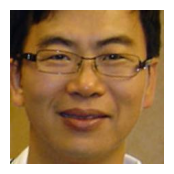

In [3]:
image = Image.open("dataset/temp/image.jpg")

plt.figure(figsize=(2,2))
plt.imshow(image)
plt.axis('off')

### CLIP

In [ ]:
from model.clip import model as clip_model, processor as clip_processor

In [ ]:
fairface_clip_model = MultiTaskViT(clip_model)

In [ ]:

for name, module in fairface_clip_model.named_modules():
    print(name, "->", type(module).__name__)

In [ ]:
print(clip_model.config)

In [ ]:
for param in fairface_clip_model.backbone.parameters():
    print(param.requires_grad)

In [60]:

for name, param in fairface_clip_model.named_parameters():
    if param.requires_grad:
        print(name)


# len(fairface_model.named_parameters())    

gender.weight
gender.bias
age.0.weight
age.0.bias
age.3.weight
age.3.bias
race.weight
race.bias


In [61]:
total = sum(p.numel() for p in fairface_clip_model.parameters())
trainable = sum(p.numel() for p in fairface_clip_model.parameters() if p.requires_grad)

print("Total:", total)
print("Trainable:", trainable)
print("Percentage:", trainable / total * 100)

Total: 86104337
Trainable: 304913
Percentage: 0.3541203737507438


In [62]:
inputs = clip_processor(
    images=image,
    return_tensors='pt'
)

In [63]:
pixel_values = inputs['pixel_values']
# print(pixel_values)
# print(inputs)


In [64]:
help(fairface_clip_model.forward)

Help on method forward in module fairface_vit:

forward(x) method of fairface_vit.FairFaceViT instance
    Define the computation performed at every call.

    Should be overridden by all subclasses.

    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [65]:
logits_dict = fairface_clip_model(pixel_values)

In [66]:
print(
    f"gender: {logits_dict['gender'].tolist()[0]}\n",
    f"age: {logits_dict['age'].tolist()[0]}\n",
    f"race: {logits_dict['race'].tolist()[0]}\n"
)

gender: [-0.4630057215690613]
 age: [-0.01415118109434843, -0.044758960604667664, 0.29030683636665344, 0.033921077847480774, -0.015230067074298859, 0.30169975757598877, 0.41551870107650757, -0.17048507928848267, 0.1753331869840622]
 race: [0.306185781955719, 0.27044081687927246, 0.5770499110221863, 0.678088366985321, -0.042987458407878876, 0.6064722537994385, 0.3233274817466736]



In [67]:
gender_prob = torch.sigmoid(logits_dict['gender'])
age_prob = torch.softmax(logits_dict['age'], dim=1)
race_prob = torch.softmax(logits_dict['race'], dim=1)

In [68]:
print(
    f"gender: {gender_prob}\n",
    f"age: {age_prob}\n",
    f"race: {race_prob}\n"
)

gender: tensor([[0.3863]], grad_fn=<SigmoidBackward0>)
 age: tensor([[0.0967, 0.0937, 0.1311, 0.1014, 0.0966, 0.1326, 0.1485, 0.0827, 0.1168]],
       grad_fn=<SoftmaxBackward0>)
 race: tensor([[0.1282, 0.1237, 0.1681, 0.1860, 0.0904, 0.1731, 0.1304]],
       grad_fn=<SoftmaxBackward0>)



### SigLip

In [ ]:
from model.siglip import model as siglip_model, processor as siglip_processor

In [ ]:
fairface_siglip_model = MultiTaskViT(siglip_model)

In [ ]:

for name, module in fairface_siglip_model.named_modules():
    print(name, "->", type(module).__name__)

In [71]:
print(siglip_model.config)

SiglipVisionConfig {
  "attention_dropout": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu_pytorch_tanh",
  "hidden_size": 768,
  "image_size": 224,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-06,
  "model_type": "siglip_vision_model",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "transformers_version": "5.12.1"
}



In [ ]:
for param in fairface_siglip_model.backbone.parameters():
    print(param.requires_grad)

In [73]:
for name, param in fairface_siglip_model.named_parameters():
    if param.requires_grad:
        print(name)

gender.weight
gender.bias
age.0.weight
age.0.bias
age.3.weight
age.3.bias
race.weight
race.bias


In [74]:
total = sum(p.numel() for p in fairface_siglip_model.parameters())
trainable = sum(p.numel() for p in fairface_siglip_model.parameters() if p.requires_grad)

print("Total:", total)
print("Trainable:", trainable)
print("Percentage:", trainable / total * 100)

Total: 93189137
Trainable: 304913
Percentage: 0.327198008068258


In [75]:
inputs = siglip_processor(
    images=image,
    return_tensors='pt'
)

In [76]:
pixel_values = inputs['pixel_values']
# print(pixel_values)
# print(inputs)

In [77]:
help(fairface_siglip_model.forward)

Help on method forward in module fairface_vit:

forward(x) method of fairface_vit.FairFaceViT instance
    Define the computation performed at every call.

    Should be overridden by all subclasses.

    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [78]:
logits_dict = fairface_siglip_model(pixel_values)

In [79]:
print(
    f"gender: {logits_dict['gender'].tolist()[0]}\n",
    f"age: {logits_dict['age'].tolist()[0]}\n",
    f"race: {logits_dict['race'].tolist()[0]}\n"
)

gender: [-0.24330711364746094]
 age: [0.041141409426927567, -0.0846727043390274, -0.07395265996456146, -0.11284536868333817, 0.23955859243869781, -0.04533543810248375, -0.10076640546321869, -0.11416561901569366, -0.18267817795276642]
 race: [-0.2454299032688141, -0.1480674147605896, -0.26524442434310913, -0.07257889211177826, -0.14290711283683777, 0.05196019262075424, -0.1188785508275032]



In [80]:
gender_prob = torch.sigmoid(logits_dict['gender'])
age_prob = torch.softmax(logits_dict['age'], dim=1)
race_prob = torch.softmax(logits_dict['race'], dim=1)

In [81]:
print(
    f"gender: {gender_prob}\n",
    f"age: {age_prob}\n",
    f"race: {race_prob}\n"
)

gender: tensor([[0.4395]], grad_fn=<SigmoidBackward0>)
 age: tensor([[0.1206, 0.1064, 0.1075, 0.1034, 0.1471, 0.1106, 0.1047, 0.1033, 0.0964]],
       grad_fn=<SoftmaxBackward0>)
 race: tensor([[0.1272, 0.1402, 0.1247, 0.1512, 0.1410, 0.1713, 0.1444]],
       grad_fn=<SoftmaxBackward0>)



### DinoV2


In [1]:
from model.dinov2 import model as dinov2_model, processor as dinov2_processor
from configs.run_configs import get_run_config
from model.adapters import apply_adapter

/home/ashkanrn/01-Project/University/Deep-Learning/DL-project/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 364.51it/s]


In [2]:
cfg = get_run_config('dinov2', 'v3')
adapter_cfg    = cfg.adapter

In [ ]:
fairface_dinov2_model = MultiTaskViT(dinov2_model)

In [6]:
fairface_dinov2_model = apply_adapter(fairface_dinov2_model, adapter_cfg)

In [ ]:

# for name, module in fairface_dinov2_model.named_modules():
#     print(name, "->", type(module).__name__)
for name, module in fairface_dinov2_model.backbone.named_modules():
    if "lora" in name.lower():
        print(name)

In [ ]:
print(dinov2_model.config)

In [ ]:
for param in fairface_dinov2_model.backbone.parameters():
    print(param.requires_grad)

In [86]:
for name, param in fairface_dinov2_model.named_parameters():
    if param.requires_grad:
        print(name)

gender.weight
gender.bias
age.0.weight
age.0.bias
age.3.weight
age.3.bias
race.weight
race.bias


In [87]:
total = sum(p.numel() for p in fairface_dinov2_model.parameters())
trainable = sum(p.numel() for p in fairface_dinov2_model.parameters() if p.requires_grad)

print("Total:", total)
print("Trainable:", trainable)
print("Percentage:", trainable / total * 100)

Total: 86885393
Trainable: 304913
Percentage: 0.35093700963060614


In [88]:
inputs = dinov2_processor(
    images=image,
    return_tensors='pt'
)

In [ ]:
print(dinov2_processor)

In [90]:
pixel_values_ = inputs['pixel_values']
# print(pixel_values)
# print(inputs)

In [91]:
help(fairface_dinov2_model.forward)

Help on method forward in module fairface_vit:

forward(x) method of fairface_vit.FairFaceViT instance
    Define the computation performed at every call.

    Should be overridden by all subclasses.

    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [92]:
logits_dict = fairface_dinov2_model(pixel_values)

In [93]:
print(
    f"gender: {logits_dict['gender'].tolist()[0]}\n",
    f"age: {logits_dict['age'].tolist()[0]}\n",
    f"race: {logits_dict['race'].tolist()[0]}\n"
)

gender: [-2.143137216567993]
 age: [0.35366469621658325, 0.08947604894638062, -0.21307852864265442, -0.546769380569458, -0.20148605108261108, 0.4676670432090759, -0.5895437002182007, 0.20774239301681519, -0.6720200777053833]
 race: [0.79090815782547, -1.9021576642990112, -1.253506064414978, -0.4074740409851074, -0.3345383107662201, -0.4809373617172241, -2.0135440826416016]



In [94]:
gender_prob = torch.sigmoid(logits_dict['gender'])
age_prob = torch.softmax(logits_dict['age'], dim=1)
race_prob = torch.softmax(logits_dict['race'], dim=1)

In [95]:
print(
    f"gender: {gender_prob}\n",
    f"age: {age_prob}\n",
    f"race: {race_prob}\n"
)

gender: tensor([[0.1050]], grad_fn=<SigmoidBackward0>)
 age: tensor([[0.1653, 0.1269, 0.0938, 0.0672, 0.0949, 0.1853, 0.0644, 0.1429, 0.0593]],
       grad_fn=<SoftmaxBackward0>)
 race: tensor([[0.4621, 0.0313, 0.0598, 0.1394, 0.1499, 0.1295, 0.0280]],
       grad_fn=<SoftmaxBackward0>)



## Validate Image Preprocessing Pipeline

In [96]:
from dataset.transforms import get_train_transform, get_age_transform
from dataset.dataloader import get_dataset, get_dataloaders


In [98]:
train_set, val_set, test_set = get_dataset()
train_dataloader, val_dataloader, test_dataloader = get_dataloaders(train_set, val_set, test_set)

In [106]:
print(len(train_dataloader.dataset))
print(len(val_dataloader.dataset))
print(len(test_dataloader.dataset))

86744
5477
5477


In [ ]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4564987..2.032137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8666667..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.598039..2.5179958].


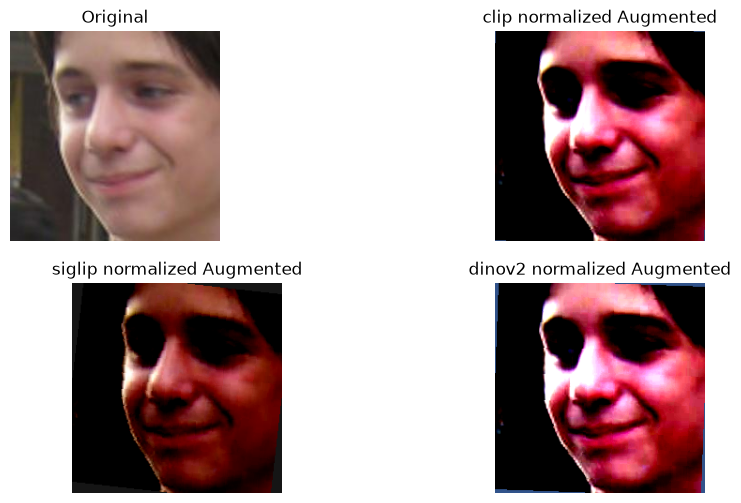

In [ ]:
img,label = train_set[8]
# plt.imshow(img)

transform = get_train_transform(clip_processor)

age_transform_clip = get_age_transform(clip_processor)
age_transform_siglip = get_age_transform(siglip_processor)
age_transform_dinov2 = get_age_transform(dinov2_processor)



plt.figure(figsize=(10,6))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

transformed_img = age_transform_clip(img)
plt.subplot(2,2,2)
plt.imshow(transformed_img.permute(1, 2, 0))
plt.title("clip normalized Augmented")
plt.axis("off")

transformed_img = age_transform_siglip(img)
plt.subplot(2,2,3)
plt.imshow(transformed_img.permute(1, 2, 0))
plt.title("siglip normalized Augmented")
plt.axis("off")

transformed_img = age_transform_dinov2(img)
plt.subplot(2,2,4)
plt.imshow(transformed_img.permute(1, 2, 0))
plt.title("dinov2 normalized Augmented")
plt.axis("off")


plt.show()

## Validate Training Pipeline

In [ ]:
from dataset.dataloader import get_dataset, get_dataloaders
from dataset.transforms import get_train_transform, get_age_transform, get_val_transform

In [ ]:
from model.clip   import model as clip_model, processor as clip_processor
from model.dinov2 import model as dinov2_model, processor as dinov2_processor
from model.siglip import model as siglip_model, processor as siglip_processor

from multitask_vit import MultiTaskViT

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
fairface_clip_model = MultiTaskViT(clip_model).to(device)

In [ ]:
train_set, val_set = get_dataset(
    get_train_transform(clip_processor.image_processor), 
    get_age_transform(clip_processor.image_processor), 
    get_val_transform(clip_processor.image_processor)
)
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [ ]:
print("number of batched: ",len(train_dataloader))
X, Y = next(iter(train_dataloader))
# images and lables blongs to 32 samples (1 batch) 

number of batched:  2711


In [ ]:
X, Y = next(iter(train_dataloader))

print("X.shape:" ,X.shape)
print("batch size:" ,X.size(0))

for k, v in Y.items():
    print(k, v.shape, v.dtype)

X.shape: torch.Size([32, 3, 224, 224])
batch size: 32
gender torch.Size([32]) torch.int64
age torch.Size([32]) torch.int64
race torch.Size([32]) torch.int64


In [ ]:
X = X.to(device)
Y = {k: v.to(device) for k, v in Y.items()}

pred = fairface_clip_model(X)
# print('pred:', pred)
print(type(pred))
print(len(pred))
    
for k, v in pred.items():
    print(k, v.shape)

<class 'dict'>
3
gender torch.Size([32, 1])
age torch.Size([32, 9])
race torch.Size([32, 7])


### Check Loss fucntions

In [ ]:
from training.losses import get_age_weights, get_loss_function, compute_losses

In [ ]:
age_labels = np.array(train_set.dataset['age'])
age_weights = get_age_weights(age_labels, 9, device)

In [ ]:
loss_funcs = get_loss_function(age_weights)

In [ ]:
print(loss_funcs)

{'gender': BCEWithLogitsLoss(), 'age': CrossEntropyLoss(), 'race': CrossEntropyLoss()}


In [ ]:
total_loss, losses = compute_losses(pred, Y, loss_funcs)



In [ ]:
print(type(total_loss), type(losses))

print(total_loss)

for key,value in losses.items():
    print(key,value)

<class 'torch.Tensor'> <class 'dict'>
tensor(5.0764, device='cuda:0', grad_fn=<AddBackward0>)
gender tensor(0.8177, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
age tensor(2.2292, device='cuda:0', grad_fn=<NllLossBackward0>)
race tensor(2.0296, device='cuda:0', grad_fn=<NllLossBackward0>)


### Check Backward

In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, fairface_clip_model.parameters()),
    lr=1e-4,
    weight_decay=0.01
)

# print(optimizer)

In [ ]:
optimizer.zero_grad()

total_loss.backward()

optimizer.step()

In [ ]:
for name, param in fairface_clip_model.named_parameters():
    if param.requires_grad:
        print(type(param))
        print(name, param.grad.abs().mean())
        break

# fairface_clip_model.named_parameters()    

<class 'torch.nn.parameter.Parameter'>
gender.weight tensor(0.1389, device='cuda:0')


### Check Train loop

In [ ]:
from training.trainer import train_loop

In [ ]:
# train_loop(train_dataloader,fairface_clip_model,loss_funcs,None,optimizer,device)

In [ ]:
from training.trainer import evaluate_loop

In [ ]:
# test_loop(train_dataloader,fairface_clip_model, loss_funcs, None,device)

## Overfitting Test on a Small Dataset Subset

In [ ]:
from model.clip import model as clip_model, processor as clip_processor

In [ ]:
from dataset.dataloader import get_dataset, get_dataloaders
from dataset.transforms import get_train_transform, get_age_transform, get_val_transform

train_set, val_set = get_dataset(
    get_train_transform(clip_processor), 
    get_age_transform(clip_processor), 
    get_val_transform(clip_processor)
)
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [ ]:
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from training.trainer import evaluate_loop

indices = list(range(30))      # first 30 samples
tiny_dataset = Subset(train_set, indices)

In [ ]:
tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=8,
    shuffle=True,
)

In [ ]:
import numpy as np
from training.trainer import train_loop,evaluate_loop



In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from multitask_vit import MultiTaskViT
fairface_clip_model = MultiTaskViT(clip_model)
fairface_clip_model.to(device)

In [ ]:
from training.losses import get_age_weights, get_loss_function, compute_losses
age_labels = np.array(train_set.dataset['age'])
age_weights = get_age_weights(age_labels, 9, device)
loss_funcs = get_loss_function(age_weights)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, fairface_clip_model.parameters()),
    lr=3e-4,
    weight_decay=0.01
)

In [ ]:
print(optimizer.param_groups[0]["lr"])

0.0003


In [ ]:
# print(fairface_clip_model.gender.state_dict())

In [ ]:
epochs = 50
avg_loss = 0.0
avg_task_losses = {}
overall = {}
subgroups_accuracy = {}
for t in range(epochs):
    print(f"Epoch {t+1}\n--------------------------------------------")
    train_loop(tiny_loader,fairface_clip_model,loss_funcs, None, optimizer, device,t+1,epochs)
    avg_loss, avg_task_losses, overall, subgroups_accuracy = evaluate_loop(tiny_loader, fairface_clip_model, loss_funcs, None, device, t+1, epochs)
    print("\n")
print("Done!")





In [ ]:
for key,value in overall.items():
    print(key,value)

gender {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
age {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'mse': 0.0, 'rmse': 0.0, 'mae': 0.0}
race {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
